# Intensity Transformations & Filtering Spatial Domain

## Thresholding : Choose a value, then separate pixels based on whether they are above or below that value.

Threshold value: 0


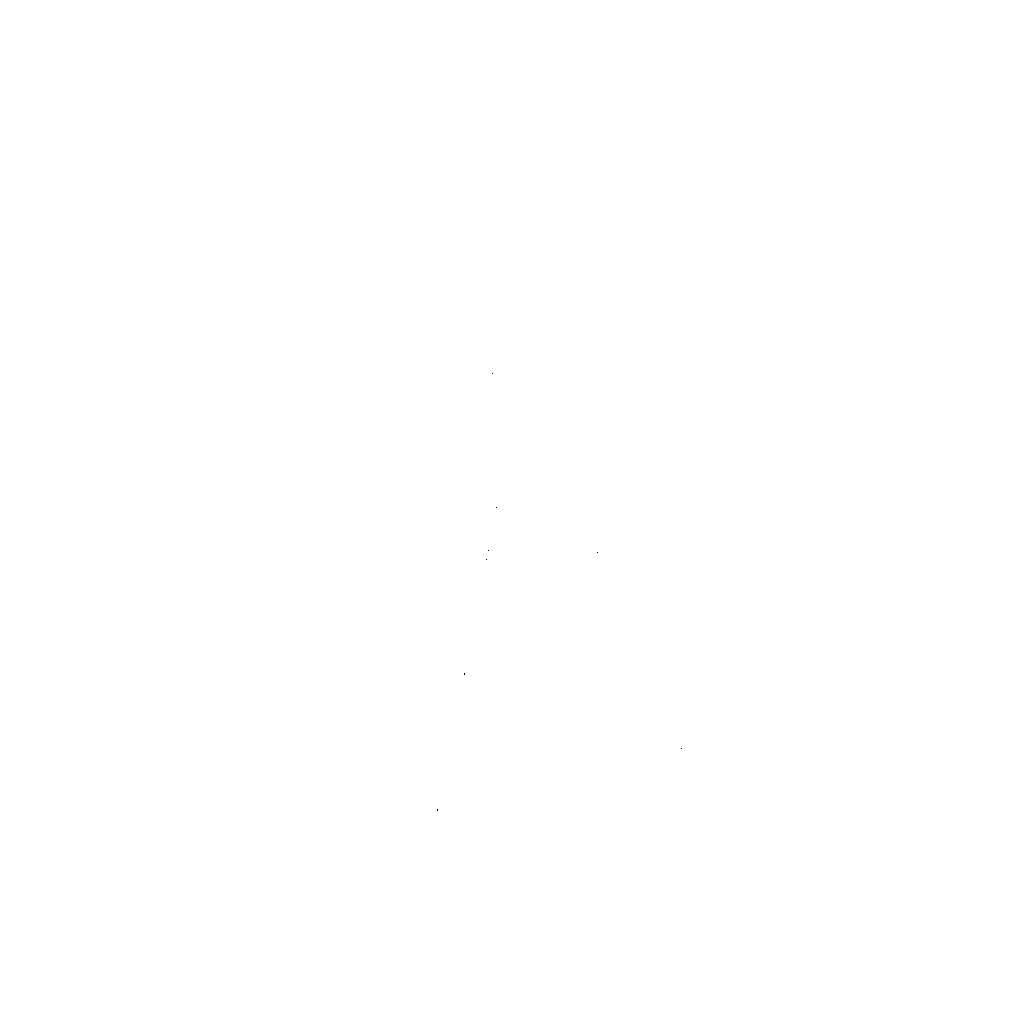

Threshold value: 50


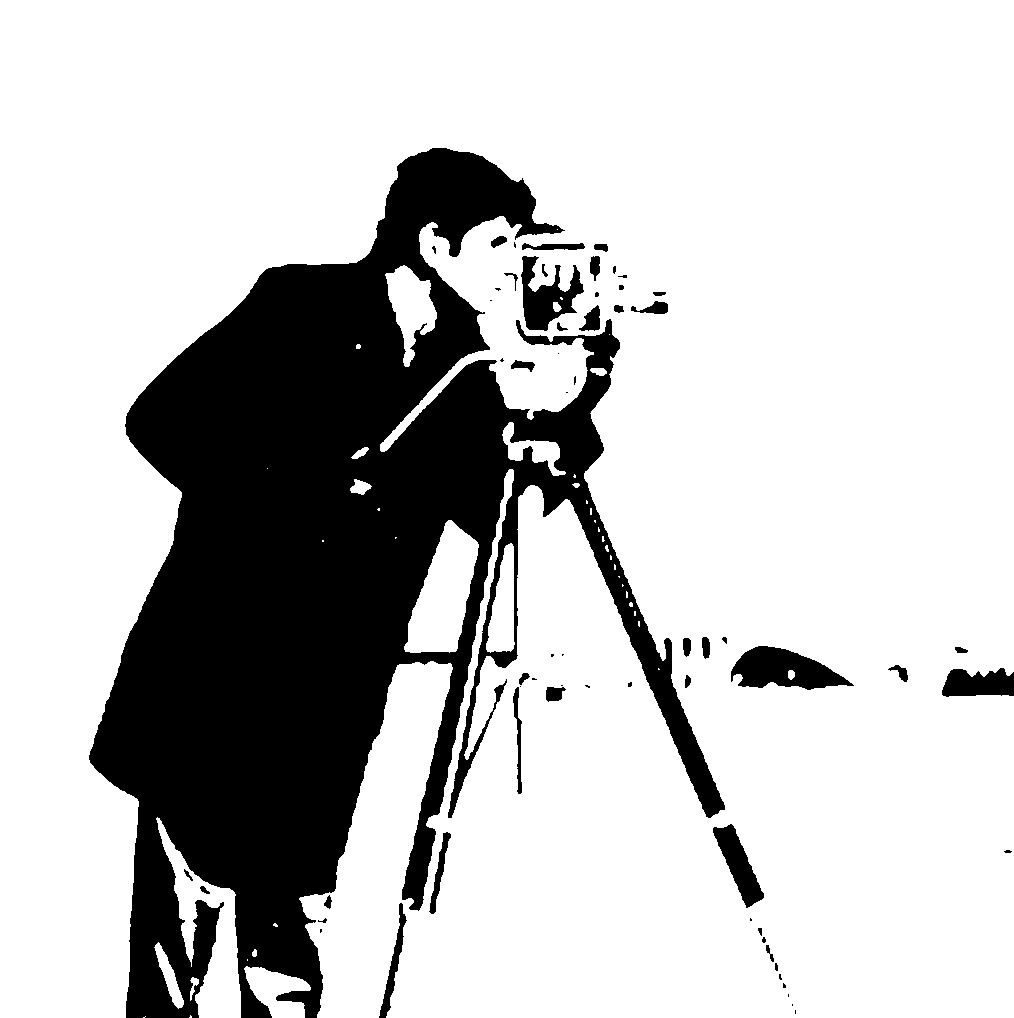

Threshold value: 100


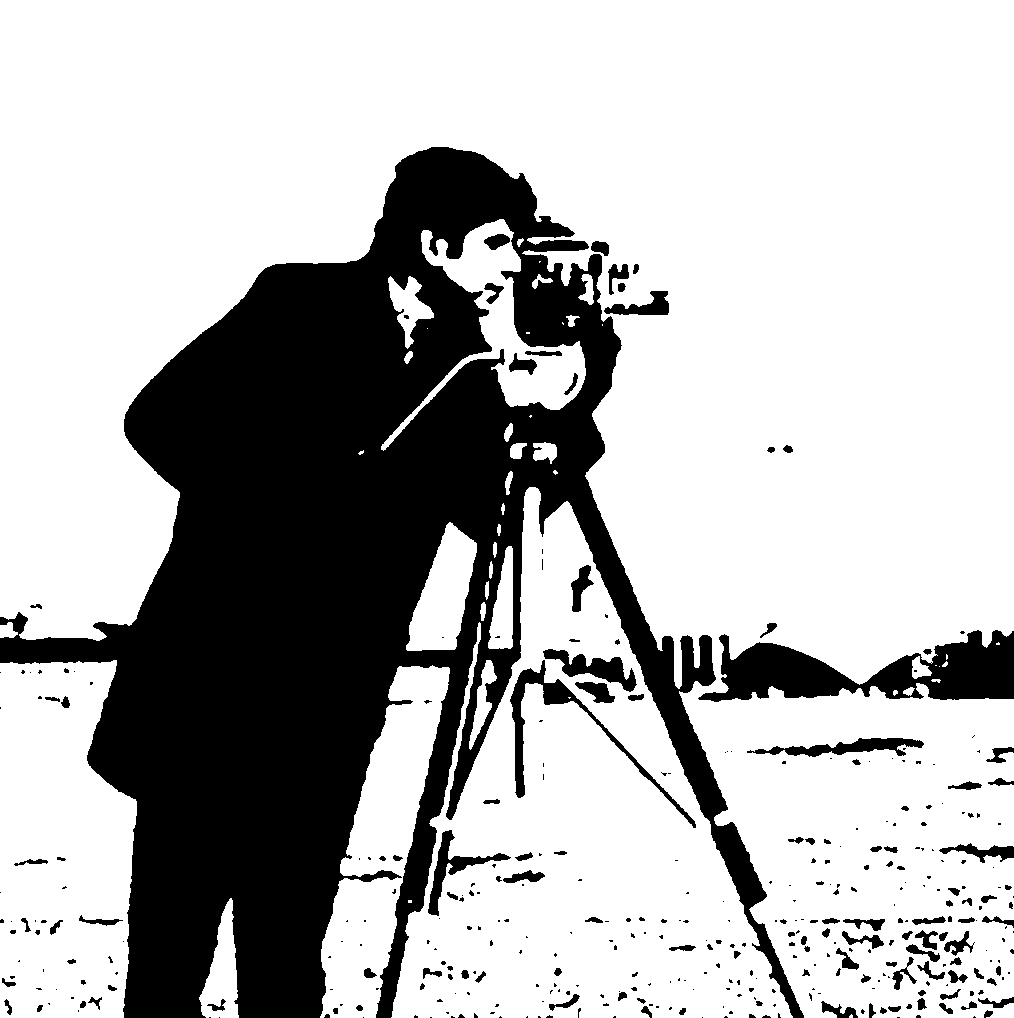

Threshold value: 150


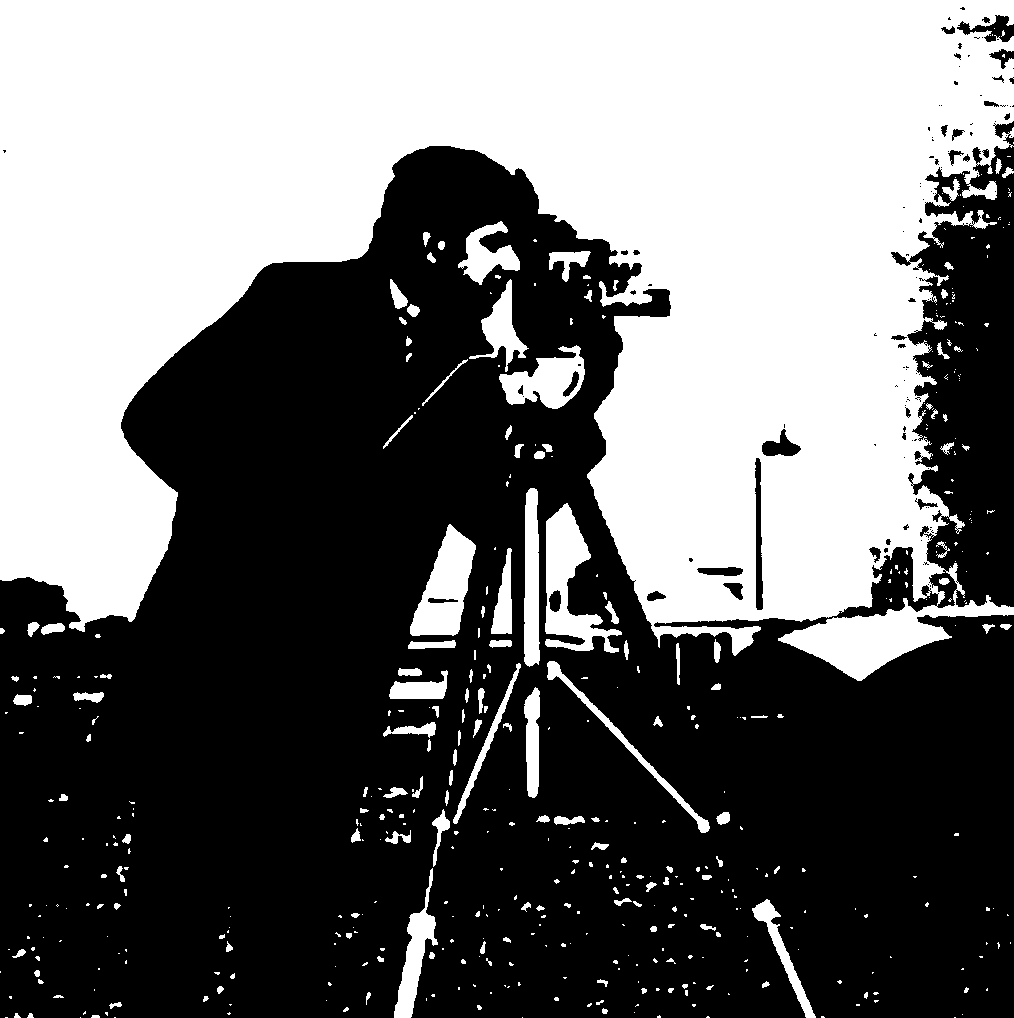

Threshold value: 200


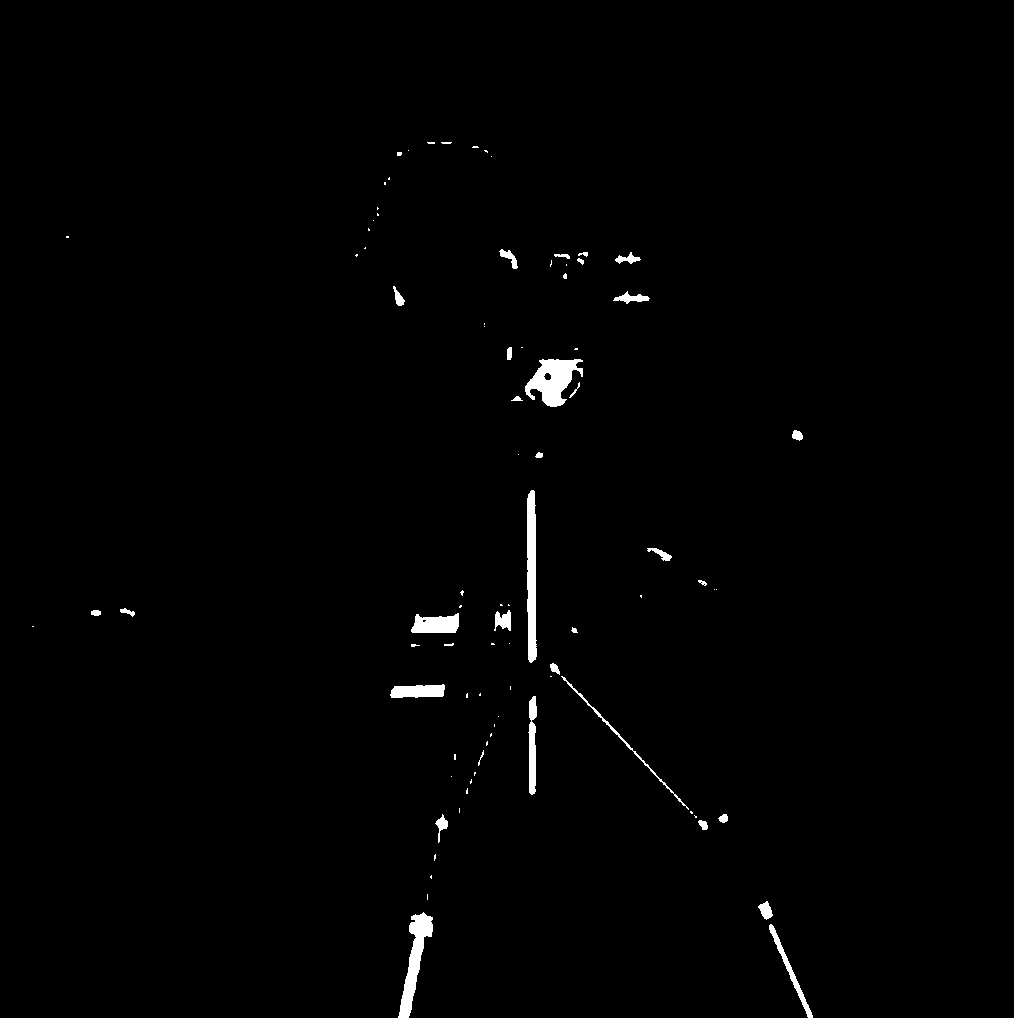

In [4]:
import cv2 #OpenCV is a library used for image processing and computer vision; to import threshold function

from google.colab.patches import cv2_imshow

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE) #Load this image as grayscale not RGB color

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]
'''0     → black
50    → dark gray
128   → medium gray
200   → light gray
255   → white
So when we perform an intensity transformation, we are changing these values.'''

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
  # the threshold value used , new processed img
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY) #(img that will be process , threshold value , 255 the max ; if pixel above 255 => white  )
'''if pixel > threshold: pixel = 255 else: pixel = 0'''

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

    '''
    Ex: pixel value : 130
        Threshold = 50
        130 > 50→ white

      Threshold = 100
       130 > 100→ white

       Threshold = 150
       130 > 150 → black

       Threshold = 200
       130 > 200 → black'''

Original Image: 


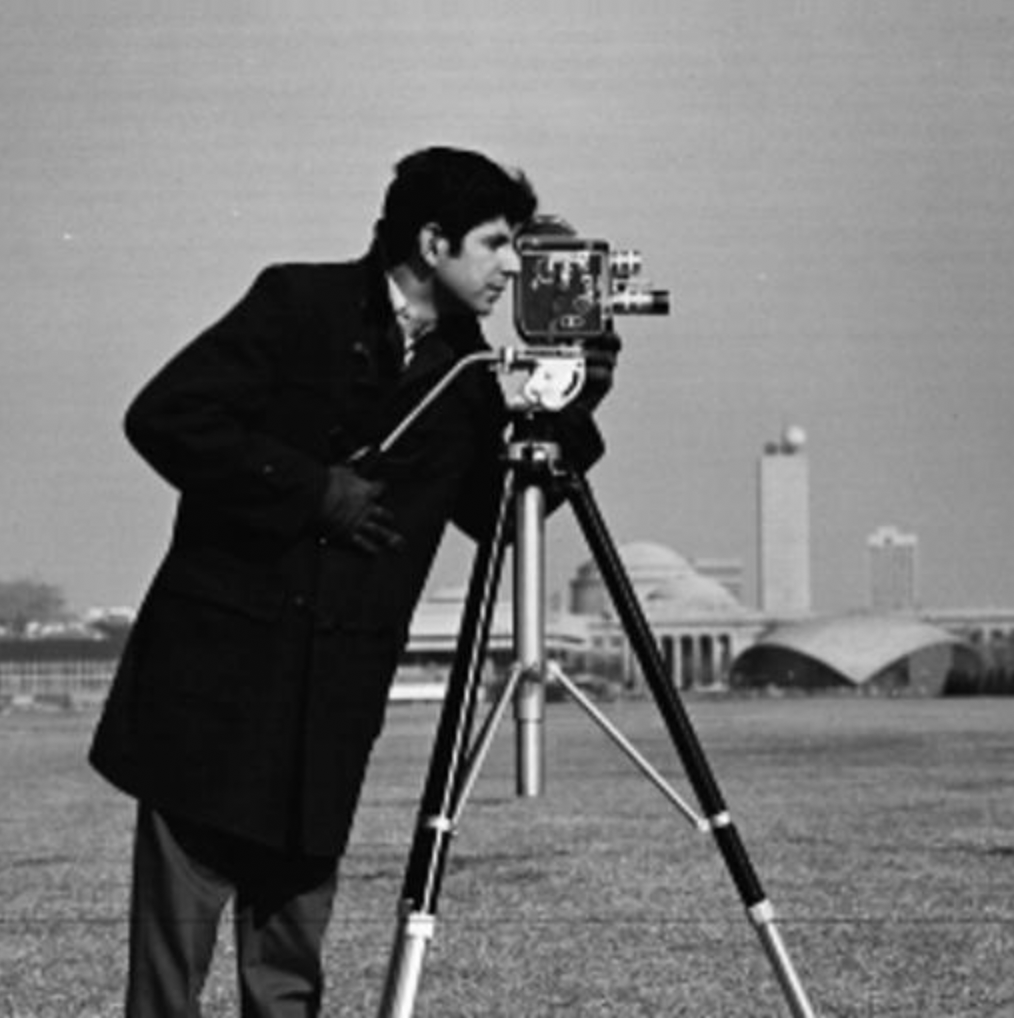

In [5]:
#to compare
print("Original Image: ")
cv2_imshow(img)

## Histograms

How many pixels have each intensity value?

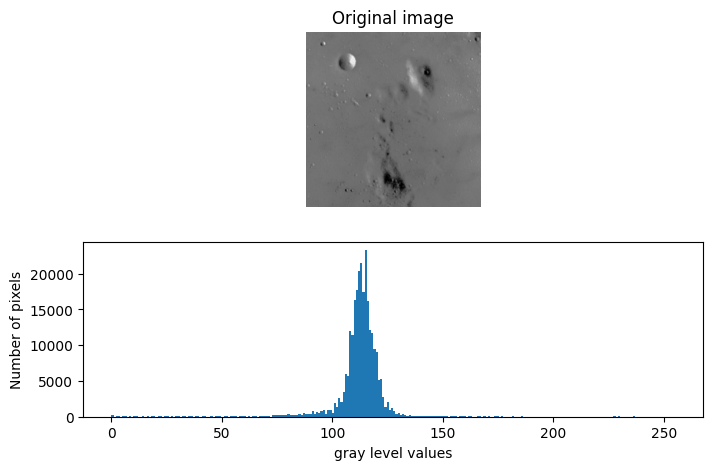

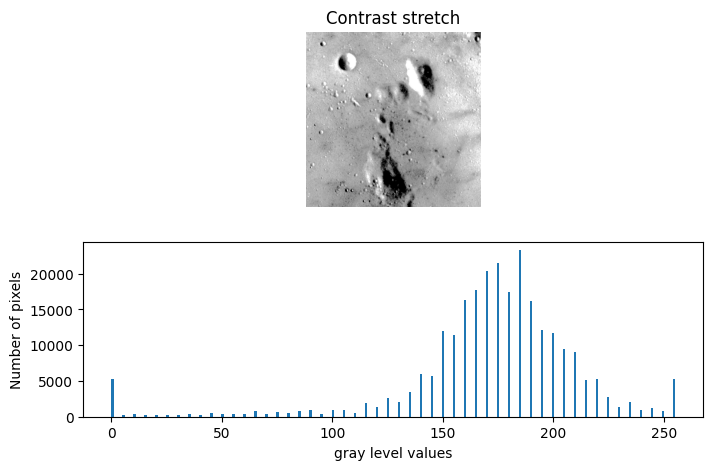

In [6]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data #contains img
from skimage import exposure #provides functions for changing image intensity and histograms

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles

# Contrast stretching :making the difference between dark and bright pixels larger, so the image becomes clearer.
'''1- Percentiles: returns the requested percentile value from the data
p2 = value below which about 2% of pixels fall
darkest ------------------------------ brightest
p98 = value below which about 98% of pixels fall

2- Rescaling: tretching or shrinking the image's intensity levels.
before : 0 -------- 80 ---- 150 -------- 255
             ↑ useful range

 After :
             80  ---------------------------- 150
             ↓                                  ↓
            0  ----------------------------- 255

So dark values become darker and bright values become brighter = inc contrast'''

p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1) #2 row , 1 column
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255)) # flat : 1D , bins : 255 , range : 0 black - 255 white
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


3rd percentile: 87.0
80th percentile: 118.0


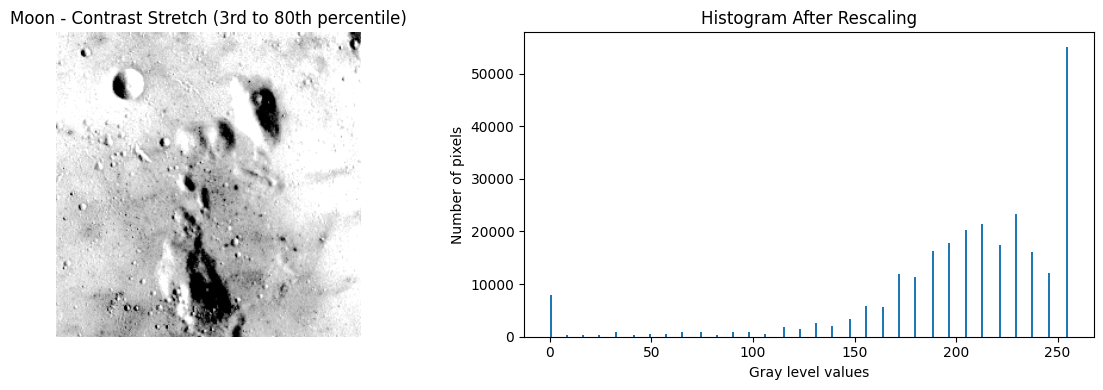

In [7]:
# Task 1

img = data.moon()

p3, p80 = np.percentile(img, (3, 80))

img_rescale_3_80 = exposure.rescale_intensity(
    img,
    in_range=(p3, p80)
)

print("3rd percentile:", p3)
print("80th percentile:", p80)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_rescale_3_80, cmap='gray')
axes[0].set_title('Moon - Contrast Stretch (3rd to 80th percentile)')
axes[0].axis('off')

axes[1].hist(
    img_rescale_3_80.ravel(),
    bins=256,
    range=(0, 255)
)
axes[1].set_title('Histogram After Rescaling')
axes[1].set_xlabel('Gray level values')
axes[1].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()

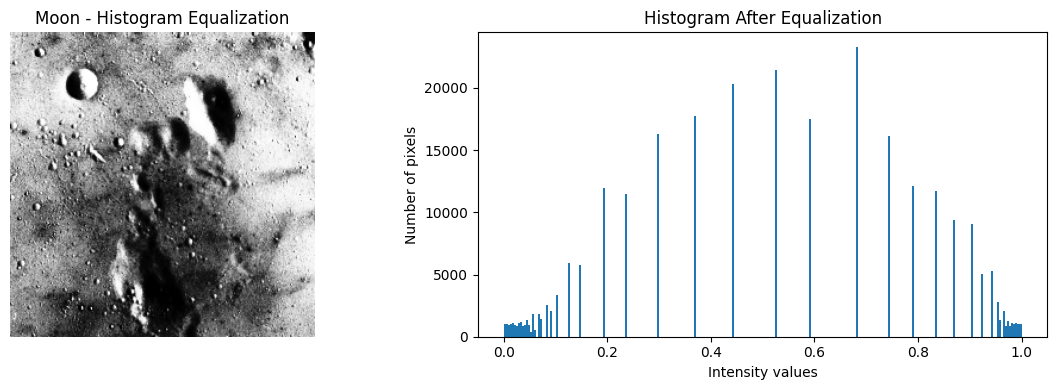

In [8]:
# Task 2

img_equalized = exposure.equalize_hist(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_equalized, cmap='gray')
axes[0].set_title('Moon - Histogram Equalization')
axes[0].axis('off')

axes[1].hist(
    img_equalized.ravel(),
    bins=256,
    range=(0, 1)
)
axes[1].set_title('Histogram After Equalization')
axes[1].set_xlabel('Intensity values')
axes[1].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()

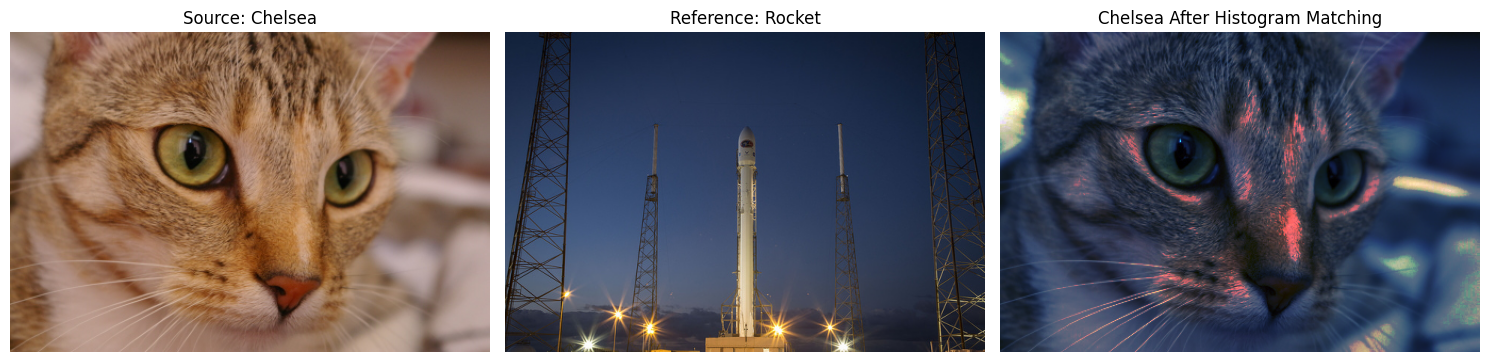

In [9]:
# Task 3

chelsea = data.chelsea()
rocket = data.rocket()

matched = exposure.match_histograms(
    chelsea,
    rocket,
    channel_axis=-1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(chelsea)
axes[0].set_title('Source: Chelsea')
axes[0].axis('off')

axes[1].imshow(rocket)
axes[1].set_title('Reference: Rocket')
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title('Chelsea After Histogram Matching')
axes[2].axis('off')

plt.tight_layout()
plt.show()